1. Execute the imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing as mp
import time
from pathlib import Path
import dask.array as da
from dask.distributed import Client, LocalCluster

1.1 Kernel + baseline

In [2]:
# Global parameters
XMIN, XMAX = -2.0, 1.0
YMIN, YMAX = -1.5, 1.5


def mandelbrot_rows(y_start, y_end, width, height, max_iter,
                    xmin=XMIN, xmax=XMAX, ymin=YMIN, ymax=YMAX):

    xs = np.linspace(xmin, xmax, width, dtype=np.float64)
    ys = np.linspace(ymin, ymax, height, dtype=np.float64)[y_start:y_end]

    c = xs[None, :] + 1j * ys[:, None]
    z = np.zeros_like(c, dtype=np.complex128)

    counts = np.zeros(c.shape, dtype=np.int32)
    active = np.ones(c.shape, dtype=bool)

    for i in range(max_iter):
        z[active] = z[active] * z[active] + c[active]

        escaped = np.abs(z) > 2.0
        newly_escaped = escaped & active

        counts[newly_escaped] = i + 1
        active &= ~escaped

        if not active.any():
            break

    counts[active] = max_iter
    return y_start, counts


def mandelbrot_single(width, height, max_iter,
                      xmin=XMIN, xmax=XMAX, ymin=YMIN, ymax=YMAX):
    _, out = mandelbrot_rows(
        0, height, width, height, max_iter,
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax
    )
    return out

2. Multiprocessing version + chunking per rows.

In [3]:
def mandelbrot_multiprocessing(width, height, max_iter, processes=4, chunk_rows=64,
                               xmin=XMIN, xmax=XMAX, ymin=YMIN, ymax=YMAX,
                               force_fork=True):
    """
    Divides the image into horizontal chunks and computes each chunk in parallel using multiprocessing.
    """
    tasks = []
    for y0 in range(0, height, chunk_rows):
        y1 = min(y0 + chunk_rows, height)
        tasks.append((y0, y1, width, height, max_iter, xmin, xmax, ymin, ymax))

    if force_fork:
        try:
            ctx = mp.get_context("fork")
        except ValueError:
            ctx = mp.get_context()
    else:
        ctx = mp.get_context()

    out = np.empty((height, width), dtype=np.int32)

    with ctx.Pool(processes=processes) as pool:
        results = pool.starmap(mandelbrot_rows, tasks, chunksize=1)

    for y0, block in results:
        out[y0:y0 + block.shape[0], :] = block

    return out


def time_numpy(func, *args, repeats=3, **kwargs):
    """
    Returns the best time (minimum) taken by func(*args, **kwargs) over the specified number of repeats.
    """
    times = []
    result = None

    for _ in range(repeats):
        t0 = time.perf_counter()
        result = func(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return min(times), result

3. Build the benchmarks

In [4]:
def benchmark_multiprocessing(
    sizes=(1024, 2048, 4096),
    max_iter=200,
    process_list=(1, 2, 4, 8),
    chunk_rows_list=(8, 16, 32, 64, 128, 256, 512),
    repeats=3,
    save_csv=True,
    csv_path="mp_results.csv"
):
    """
    Run benchmarks for different sizes, processes and chunk_rows.
    Save times and then calculate speed-up with respect to the best case with P=1.
    """
    rows = []

    for N in sizes:
        print(f"\n===== N = {N} =====")

        for P in process_list:
            for chunk_rows in chunk_rows_list:
                if chunk_rows > N:
                    continue

                elapsed, _ = time_numpy(
                    mandelbrot_multiprocessing,
                    N, N, max_iter,
                    processes=P,
                    chunk_rows=chunk_rows,
                    repeats=repeats
                )

                rows.append({
                    "N": N,
                    "max_iter": max_iter,
                    "P": P,
                    "chunk_rows": chunk_rows,
                    "time_s": elapsed
                })

                print(f"N={N:5d} | P={P:2d} | chunk_rows={chunk_rows:4d} | time={elapsed:.4f}s")

    df = pd.DataFrame(rows)

    # Best chunk for each combination (N, P)
    best_idx = df.groupby(["N", "P"])["time_s"].idxmin()
    best_df = df.loc[best_idx].copy().sort_values(["N", "P"]).reset_index(drop=True)

    # Baseline = best time with P=1 for each N
    baseline = (
        best_df[best_df["P"] == 1][["N", "time_s"]]
        .rename(columns={"time_s": "baseline_time_s"})
    )

    best_df = best_df.merge(baseline, on="N", how="left")
    best_df["speedup"] = best_df["baseline_time_s"] / best_df["time_s"]

    if save_csv:
        df.to_csv(csv_path, index=False)
        best_df.to_csv(Path(csv_path).with_name("mp_best_results.csv"), index=False)

    return df, best_df

3.1 Execute benchmarks

In [5]:
sizes = [1024, 2048, 4096]
max_iter = 200
process_list = [1, 2, 4, 8]
chunk_rows_list = [8, 16, 32, 64, 128, 256, 512]
repeats = 3

df_all, df_best = benchmark_multiprocessing(
    sizes=sizes,
    max_iter=max_iter,
    process_list=process_list,
    chunk_rows_list=chunk_rows_list,
    repeats=repeats,
    save_csv=True,
    csv_path="mp_results.csv"
)

print("\n--- All results ---")
display(df_all)

print("\n--- Best chunk for each (N, P) ---")
display(df_best)


===== N = 1024 =====


N= 1024 | P= 1 | chunk_rows=   8 | time=2.2206s


N= 1024 | P= 1 | chunk_rows=  16 | time=1.9252s


N= 1024 | P= 1 | chunk_rows=  32 | time=1.7821s


N= 1024 | P= 1 | chunk_rows=  64 | time=1.7244s


...

N= 4096 | P= 8 | chunk_rows= 512 | time=37.1879s



--- All results ---


,N,max_iter,P,chunk_rows,time_s
0,1024,200,1,8,2.220595
1,1024,200,1,16,1.925191
2,1024,200,1,32,1.782128
3,1024,200,1,64,1.724426
4,1024,200,1,128,1.845113
...,...,...,...,...,...
79,4096,200,8,32,30.797177
80,4096,200,8,64,33.595985
81,4096,200,8,128,35.779775
82,4096,200,8,256,36.445889



--- Best chunk for each (N, P) ---


,N,max_iter,P,chunk_rows,time_s,baseline_time_s,speedup
0,1024,200,1,64,1.724426,1.724426,1.000000
1,1024,200,2,32,1.866575,1.724426,0.923845
2,1024,200,4,32,2.029962,1.724426,0.849487
3,1024,200,8,32,2.064298,1.724426,0.835357
4,2048,200,1,32,6.590750,6.590750,1.000000
5,2048,200,2,16,6.893627,6.590750,0.956064
6,2048,200,4,16,7.423315,6.590750,0.887845
7,2048,200,8,16,7.427028,6.590750,0.887401
8,4096,200,1,16,25.115513,25.115513,1.000000
9,4096,200,2,8,26.416791,25.115513,0.950740


4. Graphs for optimal chunk and speed-up

In [6]:
def plot_best_chunk_vs_processes(df_best, N):
    sub = df_best[df_best["N"] == N].sort_values("P")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["P"], sub["chunk_rows"], marker="o")
    plt.xlabel("Número de procesos (P)")
    plt.ylabel("Chunk size óptimo (filas)")
    plt.title(f"Chunk size óptimo vs P (N={N})")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_time_vs_processes(df_best, N):
    sub = df_best[df_best["N"] == N].sort_values("P")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["P"], sub["time_s"], marker="o")
    plt.xlabel("Número de procesos (P)")
    plt.ylabel("Tiempo (s)")
    plt.title(f"Tiempo vs P usando el mejor chunk (N={N})")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_speedup_vs_processes(df_best, N):
    sub = df_best[df_best["N"] == N].sort_values("P")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["P"], sub["speedup"], marker="o", label="Speed-up medido")
    plt.plot(sub["P"], sub["P"], linestyle="--", label="Ideal")
    plt.xlabel("Número de procesos (P)")
    plt.ylabel("Speed-up")
    plt.title(f"Speed-up vs P usando el mejor chunk (N={N})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

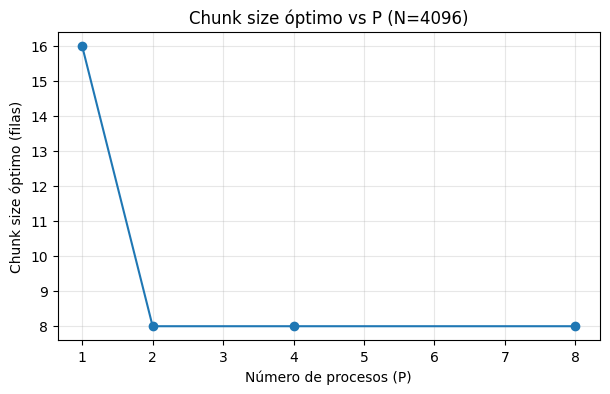

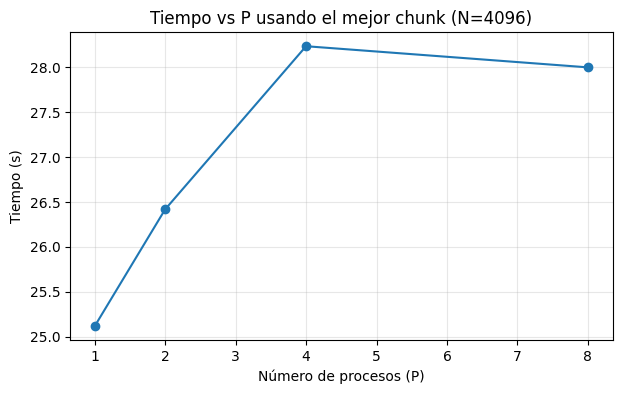

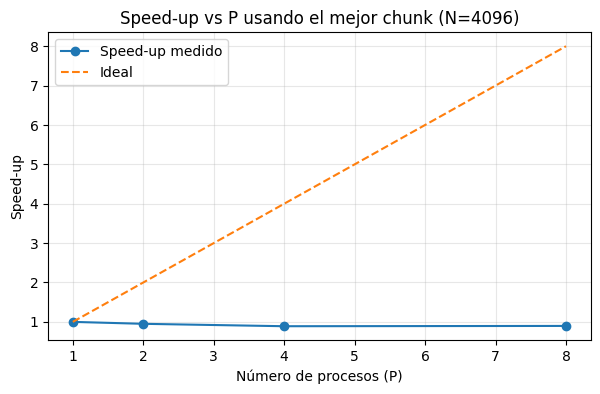

In [7]:
# Fixed size example
N_plot = 4096

plot_best_chunk_vs_processes(df_best, N_plot)
plot_time_vs_processes(df_best, N_plot)
plot_speedup_vs_processes(df_best, N_plot)

5. Mandelbrot block

In [8]:
def mandelbrot_block(c_block, max_iter):
    z = np.zeros_like(c_block, dtype=np.complex128)
    counts = np.zeros(c_block.shape, dtype=np.int32)
    active = np.ones(c_block.shape, dtype=bool)

    for i in range(max_iter):
        z[active] = z[active] * z[active] + c_block[active]

        escaped = np.abs(z) > 2.0
        newly_escaped = escaped & active

        counts[newly_escaped] = i + 1
        active &= ~escaped

        if not active.any():
            break

    counts[active] = max_iter
    return counts

6. Dask version


In [9]:
def mandelbrot_dask(width, height, max_iter,
                    chunk_rows=256, chunk_cols=256,
                    xmin=XMIN, xmax=XMAX, ymin=YMIN, ymax=YMAX):
    """
    Devuelve un Dask array lazy, todavía sin computar.
    """

    x = da.linspace(xmin, xmax, width, chunks=chunk_cols)
    y = da.linspace(ymin, ymax, height, chunks=chunk_rows)

    X, Y = da.meshgrid(x, y)
    c = X + 1j * Y

    out = c.map_blocks(
        mandelbrot_block,
        max_iter=max_iter,
        dtype=np.int32
    )

    return out

6.1 Local client on Dask

In [10]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    processes=True
)

client = Client(cluster)
client

/home/ubuntu/NSC/.venv/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37857 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:37857/status,
Dashboard: http://127.0.0.1:37857/status,Workers: 4
Total threads: 4,Total memory: 3.82 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42993,Workers: 0
Dashboard: http://127.0.0.1:37857/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39049,Total threads: 1
Dashboard: http://127.0.0.1:43527/status,Memory: 0.96 GiB
Nanny: tcp://127.0.0.1:46761,


7. Local execution timing


In [11]:
def time_dask_local(width, height, max_iter,
                    chunk_rows=256, chunk_cols=256,
                    repeats=3):
    times = []
    last = None

    for _ in range(repeats):
        arr = mandelbrot_dask(
            width=width,
            height=height,
            max_iter=max_iter,
            chunk_rows=chunk_rows,
            chunk_cols=chunk_cols
        )

        t0 = time.perf_counter()
        last = arr.compute()
        t1 = time.perf_counter()

        times.append(t1 - t0)

    return min(times), last

In [12]:
elapsed, img = time_dask_local(
    width=2048,
    height=2048,
    max_iter=200,
    chunk_rows=256,
    chunk_cols=256,
    repeats=3
)

print(f"Local Dask Time: {elapsed:.4f} s")

Local Dask Time: 19.0088 s


8. Dask benchmarks

In [13]:
def benchmark_dask_local(
    sizes=(1024, 2048, 4096),
    max_iter=200,
    workers_list=(1, 2, 4, 8),
    chunk_list=(64, 128, 256, 512),
    repeats=3,
    save_csv=True,
    csv_path="dask_local_results.csv"
):
    rows = []

    for N in sizes:
        print(f"\n===== N = {N} =====")

        for workers in workers_list:
            cluster = LocalCluster(
                n_workers=workers,
                threads_per_worker=1,
                processes=True,
                dashboard_address=None
            )
            client = Client(cluster)

            try:
                for chunk in chunk_list:
                    if chunk > N:
                        continue

                    times = []

                    for _ in range(repeats):
                        arr = mandelbrot_dask(
                            width=N,
                            height=N,
                            max_iter=max_iter,
                            chunk_rows=chunk,
                            chunk_cols=chunk
                        )

                        t0 = time.perf_counter()
                        _ = arr.compute()
                        t1 = time.perf_counter()

                        times.append(t1 - t0)

                    elapsed = min(times)

                    rows.append({
                        "N": N,
                        "max_iter": max_iter,
                        "workers": workers,
                        "chunk_rows": chunk,
                        "chunk_cols": chunk,
                        "time_s": elapsed
                    })

                    print(f"N={N:5d} | workers={workers:2d} | chunk={chunk:4d} | time={elapsed:.4f}s")

            finally:
                client.close()
                cluster.close()

    df = pd.DataFrame(rows)

    best_idx = df.groupby(["N", "workers"])["time_s"].idxmin()
    best_df = df.loc[best_idx].copy().sort_values(["N", "workers"]).reset_index(drop=True)

    baseline = (
        best_df[best_df["workers"] == 1][["N", "time_s"]]
        .rename(columns={"time_s": "baseline_time_s"})
    )

    best_df = best_df.merge(baseline, on="N", how="left")
    best_df["speedup"] = best_df["baseline_time_s"] / best_df["time_s"]

    if save_csv:
        df.to_csv(csv_path, index=False)
        best_df.to_csv("dask_local_best_results.csv", index=False)

    return df, best_df

9. Local benchmarks

In [14]:
df_dask_all, df_dask_best = benchmark_dask_local(
    sizes=(1024, 2048, 4096),
    max_iter=200,
    workers_list=(1, 2, 4, 8),
    chunk_list=(64, 128, 256, 512),
    repeats=3,
    save_csv=True,
    csv_path="dask_local_results.csv"
)

display(df_dask_all)
display(df_dask_best)


===== N = 1024 =====


/home/ubuntu/NSC/.venv/lib/python3.10/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34477 instead
  warnings.warn(


N= 1024 | workers= 1 | chunk=  64 | time=7.1468s


N= 1024 | workers= 1 | chunk= 128 | time=5.4590s


N= 1024 | workers= 1 | chunk= 256 | time=5.0262s


...

N= 4096 | workers= 8 | chunk= 128 | time=108.6766s


N= 4096 | workers= 8 | chunk= 256 | time=100.6159s


N= 4096 | workers= 8 | chunk= 512 | time=118.7090s


,N,max_iter,workers,chunk_rows,chunk_cols,time_s
0,1024,200,1,64,64,7.146818
1,1024,200,1,128,128,5.459027
2,1024,200,1,256,256,5.026168
3,1024,200,1,512,512,6.663723
4,1024,200,2,64,64,9.289989
5,1024,200,2,128,128,5.907900
6,1024,200,2,256,256,5.898380
7,1024,200,2,512,512,7.707547
8,1024,200,4,64,64,9.838507
9,1024,200,4,128,128,8.020906


,N,max_iter,workers,chunk_rows,chunk_cols,time_s,baseline_time_s,speedup
0,1024,200,1,256,256,5.026168,5.026168,1.000000
1,1024,200,2,256,256,5.898380,5.026168,0.852127
2,1024,200,4,256,256,7.587723,5.026168,0.662408
3,1024,200,8,256,256,10.716017,5.026168,0.469033
4,2048,200,1,128,128,11.545526,11.545526,1.000000
5,2048,200,2,128,128,15.271027,11.545526,0.756041
6,2048,200,4,128,128,22.734231,11.545526,0.507848
7,2048,200,8,128,128,30.485505,11.545526,0.378722
8,4096,200,1,256,256,30.047098,30.047098,1.000000
9,4096,200,2,256,256,41.821330,30.047098,0.718463


10. Dask graphs

In [15]:
def plot_dask_chunk_vs_workers(df_best, N):
    sub = df_best[df_best["N"] == N].sort_values("workers")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["workers"], sub["chunk_rows"], marker="o")
    plt.xlabel("Workers")
    plt.ylabel("Chunk óptimo")
    plt.title(f"Dask local: chunk óptimo vs workers (N={N})")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_dask_time_vs_workers(df_best, N):
    sub = df_best[df_best["N"] == N].sort_values("workers")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["workers"], sub["time_s"], marker="o")
    plt.xlabel("Workers")
    plt.ylabel("Tiempo (s)")
    plt.title(f"Dask local: tiempo vs workers (N={N})")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_dask_speedup_vs_workers(df_best, N):
    sub = df_best[df_best["N"] == N].sort_values("workers")

    plt.figure(figsize=(7, 4))
    plt.plot(sub["workers"], sub["speedup"], marker="o", label="Speed-up medido")
    plt.plot(sub["workers"], sub["workers"], linestyle="--", label="Ideal")
    plt.xlabel("Workers")
    plt.ylabel("Speed-up")
    plt.title(f"Dask local: speed-up vs workers (N={N})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

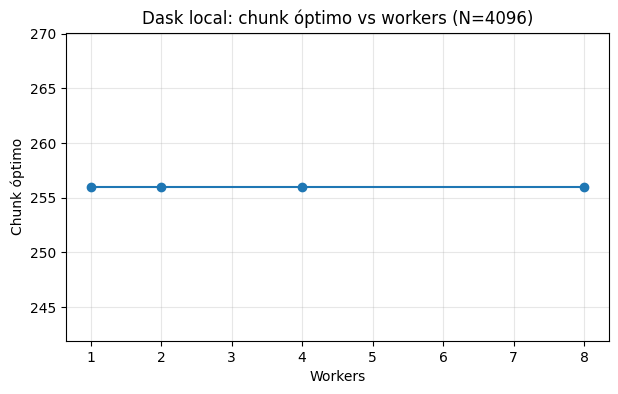

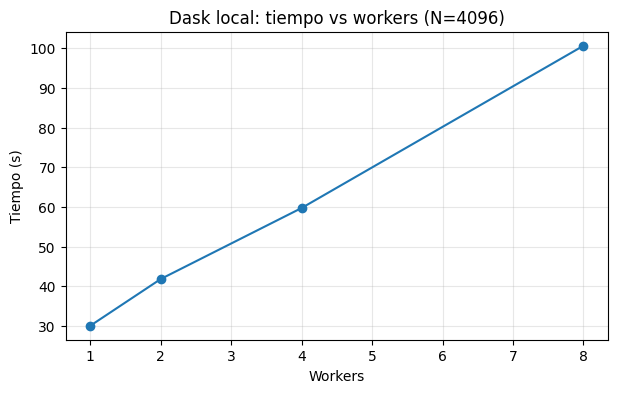

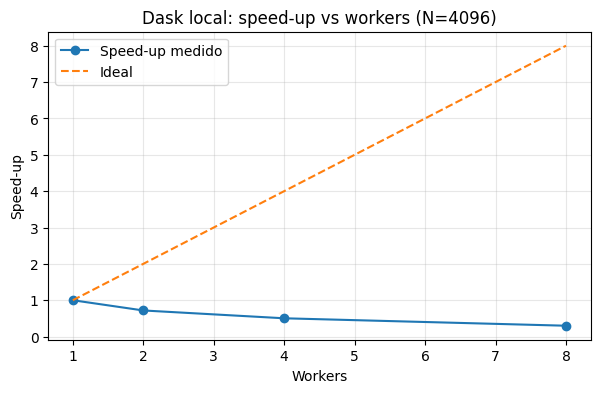

In [16]:
N_plot = 4096

plot_dask_chunk_vs_workers(df_dask_best, N_plot)
plot_dask_time_vs_workers(df_dask_best, N_plot)
plot_dask_speedup_vs_workers(df_dask_best, N_plot)

11. Numpy vs Dask

In [17]:
sizes = [1024, 2048, 4096]
rows = []

for N in sizes:
    t_np, _ = time_numpy(mandelbrot_single, N, N, 200, repeats=3)
    t_dask, _ = time_dask_local(N, N, 200, chunk_rows=256, chunk_cols=256, repeats=3)

    rows.append({
        "N": N,
        "numpy_time_s": t_np,
        "dask_time_s": t_dask,
        "speedup_dask_vs_numpy": t_np / t_dask
    })

df_np_vs_dask = pd.DataFrame(rows)
display(df_np_vs_dask)

,N,numpy_time_s,dask_time_s,speedup_dask_vs_numpy
0,1024,3.265413,5.027043,0.649569
1,2048,13.192670,17.336637,0.760971
2,4096,62.504898,63.233732,0.988474


12. Dask Cluster

In [18]:
client = Client("tcp://10.92.0.79:8786")
client

/home/ubuntu/NSC/.venv/lib/python3.10/site-packages/distributed/client.py:1607: VersionMismatchWarning: Mismatched versions found

+---------+--------+-----------+---------+
| Package | Client | Scheduler | Workers |
+---------+--------+-----------+---------+
| tornado | 6.5.4  | 6.5.4     | 6.5.5   |
+---------+--------+-----------+---------+
  warnings.warn(version_module.VersionMismatchWarning(msg[0]["warning"]))


<Client: 'tcp://10.92.0.79:8786' processes=2 threads=2, memory=0 B>

Workers

In [19]:
client.scheduler_info()["workers"].keys()

dict_keys(['tcp://10.92.0.110:34345', 'tcp://10.92.0.180:43393'])

12.1 Light test just to see if all works 

In [20]:
arr = mandelbrot_dask(
    width=1024,
    height=1024,
    max_iter=200,
    chunk_rows=256,
    chunk_cols=256
)

%time img = arr.compute()

CPU times: user 109 ms, sys: 9.67 ms, total: 119 ms
Wall time: 2.17 s


12.2 Build dask benchmarks

In [21]:
def benchmark_dask_cluster(
    client,
    sizes=(1024, 2048, 4096),
    max_iter=200,
    chunk_list=(64, 128, 256, 512),
    repeats=3,
    save_csv=True,
    csv_path="dask_cluster_results.csv"
):
    rows = []

    info = client.scheduler_info()
    n_workers = len(info["workers"])

    print(f"Workers conectados al cluster: {n_workers}")
    for w in info["workers"]:
        print(" -", w)

    for N in sizes:
        print(f"\n===== N = {N} =====")

        for chunk in chunk_list:
            if chunk > N:
                continue

            times = []

            for _ in range(repeats):
                arr = mandelbrot_dask(
                    width=N,
                    height=N,
                    max_iter=max_iter,
                    chunk_rows=chunk,
                    chunk_cols=chunk
                )

                t0 = time.perf_counter()
                _ = arr.compute()
                t1 = time.perf_counter()

                times.append(t1 - t0)

            elapsed = min(times)

            rows.append({
                "N": N,
                "max_iter": max_iter,
                "workers": n_workers,
                "chunk_rows": chunk,
                "chunk_cols": chunk,
                "time_s": elapsed
            })

            print(f"N={N:5d} | workers={n_workers:2d} | chunk={chunk:4d} | time={elapsed:.4f}s")

    df = pd.DataFrame(rows)

    best_idx = df.groupby(["N"])["time_s"].idxmin()
    best_df = df.loc[best_idx].copy().sort_values(["N"]).reset_index(drop=True)

    if save_csv:
        df.to_csv(csv_path, index=False)
        best_df.to_csv("dask_cluster_best_results.csv", index=False)

    return df, best_df

13. Cluster's benchmarks

In [22]:
df_cluster_all, df_cluster_best = benchmark_dask_cluster(
    client=client,
    sizes=(1024, 2048, 4096),
    max_iter=200,
    chunk_list=(64, 128, 256, 512),
    repeats=3,
    csv_path="dask_cluster_results.csv"
)

display(df_cluster_all)
display(df_cluster_best)

Workers conectados al cluster: 2
 - tcp://10.92.0.110:34345
 - tcp://10.92.0.180:43393

===== N = 1024 =====


N= 1024 | workers= 2 | chunk=  64 | time=1.4467s


N= 1024 | workers= 2 | chunk= 128 | time=1.3920s


N= 1024 | workers= 2 | chunk= 256 | time=1.4540s


N= 1024 | workers= 2 | chunk= 512 | time=1.7745s

===== N = 2048 =====


...

N= 4096 | workers= 2 | chunk= 128 | time=10.0360s


N= 4096 | workers= 2 | chunk= 256 | time=8.5523s


N= 4096 | workers= 2 | chunk= 512 | time=13.3722s


,N,max_iter,workers,chunk_rows,chunk_cols,time_s
0,1024,200,2,64,64,1.446671
1,1024,200,2,128,128,1.392033
2,1024,200,2,256,256,1.454012
3,1024,200,2,512,512,1.774501
4,2048,200,2,64,64,5.118805
5,2048,200,2,128,128,2.837545
6,2048,200,2,256,256,3.234656
7,2048,200,2,512,512,5.442524
8,4096,200,2,64,64,19.153997
9,4096,200,2,128,128,10.036009


,N,max_iter,workers,chunk_rows,chunk_cols,time_s
0,1024,200,2,128,128,1.392033
1,2048,200,2,128,128,2.837545
2,4096,200,2,256,256,8.552333


Comparative table

In [23]:
summary_rows = []

sizes_summary = sorted(df_best["N"].unique())

for N in sizes_summary:
    # NumPy
    np_row = df_np_vs_dask[df_np_vs_dask["N"] == N].iloc[0]

    # Multiprocessing
    mp_row = df_best[df_best["N"] == N].sort_values("time_s").iloc[0]

    # Dask local
    dask_local_row = df_dask_best[df_dask_best["N"] == N].sort_values("time_s").iloc[0]

    # Dask cluster
    dask_cluster_row = df_cluster_best[df_cluster_best["N"] == N].sort_values("time_s").iloc[0]

    summary_rows.append({
        "N": N,

        "numpy_time_s": np_row["numpy_time_s"],

        "mp_best_time_s": mp_row["time_s"],
        "mp_best_P": mp_row["P"],
        "mp_best_chunk": mp_row["chunk_rows"],
        "mp_speedup_vs_numpy": np_row["numpy_time_s"] / mp_row["time_s"],

        "dask_local_best_time_s": dask_local_row["time_s"],
        "dask_local_best_workers": dask_local_row["workers"],
        "dask_local_best_chunk": dask_local_row["chunk_rows"],
        "dask_local_speedup_vs_numpy": np_row["numpy_time_s"] / dask_local_row["time_s"],

        "dask_cluster_best_time_s": dask_cluster_row["time_s"],
        "dask_cluster_best_workers": dask_cluster_row["workers"],
        "dask_cluster_best_chunk": dask_cluster_row["chunk_rows"],
        "dask_cluster_speedup_vs_numpy": np_row["numpy_time_s"] / dask_cluster_row["time_s"],
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,N,numpy_time_s,mp_best_time_s,mp_best_P,mp_best_chunk,mp_speedup_vs_numpy,dask_local_best_time_s,dask_local_best_workers,dask_local_best_chunk,dask_local_speedup_vs_numpy,dask_cluster_best_time_s,dask_cluster_best_workers,dask_cluster_best_chunk,dask_cluster_speedup_vs_numpy
0,1024,3.265413,1.724426,1.0,64.0,1.893623,5.026168,1.0,256.0,0.649682,1.392033,2.0,128.0,2.345788
1,2048,13.192670,6.590750,1.0,32.0,2.001695,11.545526,1.0,128.0,1.142665,2.837545,2.0,128.0,4.649326
2,4096,62.504898,25.115513,1.0,16.0,2.488697,30.047098,1.0,256.0,2.080231,8.552333,2.0,256.0,7.308520


In [24]:
df_summary.to_csv("final_comparison_summary.csv", index=False)

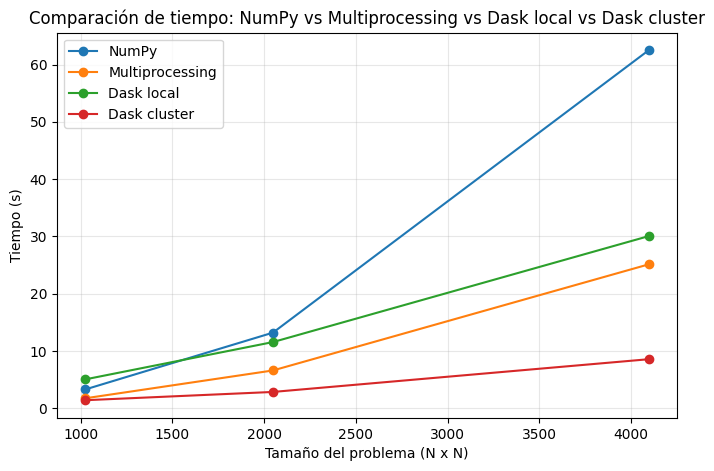

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(df_summary["N"], df_summary["numpy_time_s"], marker="o", label="NumPy")
plt.plot(df_summary["N"], df_summary["mp_best_time_s"], marker="o", label="Multiprocessing")
plt.plot(df_summary["N"], df_summary["dask_local_best_time_s"], marker="o", label="Dask local")
plt.plot(df_summary["N"], df_summary["dask_cluster_best_time_s"], marker="o", label="Dask cluster")

plt.xlabel("Tamaño del problema (N x N)")
plt.ylabel("Tiempo (s)")
plt.title("Comparación de tiempo: NumPy vs Multiprocessing vs Dask local vs Dask cluster")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Speed-up vs Numpy

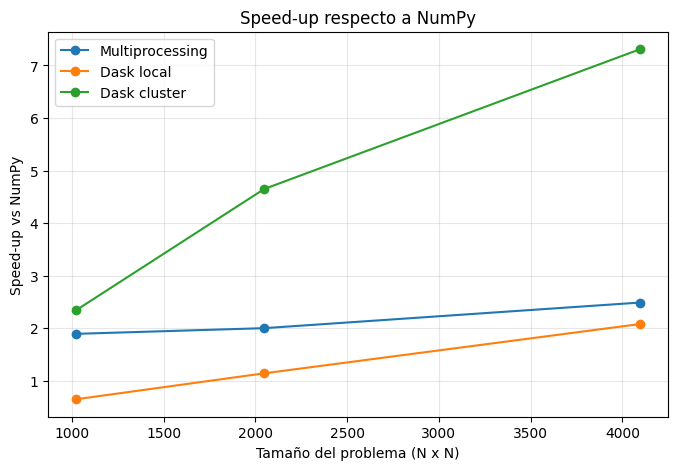

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(df_summary["N"], df_summary["mp_speedup_vs_numpy"], marker="o", label="Multiprocessing")
plt.plot(df_summary["N"], df_summary["dask_local_speedup_vs_numpy"], marker="o", label="Dask local")
plt.plot(df_summary["N"], df_summary["dask_cluster_speedup_vs_numpy"], marker="o", label="Dask cluster")

plt.xlabel("Tamaño del problema (N x N)")
plt.ylabel("Speed-up vs NumPy")
plt.title("Speed-up respecto a NumPy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [27]:
df_summary_rounded = df_summary.copy()

cols_to_round = [
    "numpy_time_s",
    "mp_best_time_s",
    "mp_speedup_vs_numpy",
    "dask_local_best_time_s",
    "dask_local_speedup_vs_numpy",
    "dask_cluster_best_time_s",
    "dask_cluster_speedup_vs_numpy"
]

df_summary_rounded[cols_to_round] = df_summary_rounded[cols_to_round].round(4)

display(df_summary_rounded)

,N,numpy_time_s,mp_best_time_s,mp_best_P,mp_best_chunk,mp_speedup_vs_numpy,dask_local_best_time_s,dask_local_best_workers,dask_local_best_chunk,dask_local_speedup_vs_numpy,dask_cluster_best_time_s,dask_cluster_best_workers,dask_cluster_best_chunk,dask_cluster_speedup_vs_numpy
0,1024,3.2654,1.7244,1.0,64.0,1.8936,5.0262,1.0,256.0,0.6497,1.3920,2.0,128.0,2.3458
1,2048,13.1927,6.5908,1.0,32.0,2.0017,11.5455,1.0,128.0,1.1427,2.8375,2.0,128.0,4.6493
2,4096,62.5049,25.1155,1.0,16.0,2.4887,30.0471,1.0,256.0,2.0802,8.5523,2.0,256.0,7.3085


Numpy vs Dask

In [28]:
sizes = sorted(df_best["N"].unique())
rows = []

for N in sizes:
    t_np, _ = time_numpy(mandelbrot_single, N, N, 200, repeats=3)

    rows.append({
        "N": N,
        "numpy_time_s": t_np
    })

df_np_vs_dask = pd.DataFrame(rows)
display(df_np_vs_dask)

,N,numpy_time_s
0,1024,3.225810
1,2048,13.100748
2,4096,61.765509
